# AI-Driven Tech Layoff Analysis (2026)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("tech_layoff_2026.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_") 
df.head(5)

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [3]:
for col in df.select_dtypes(include='object'):
    print(f"column : {col}")
    print(df[col].unique())
    print("\n")

column : company
['Amazon' 'Block' 'Meta Reality Labs' 'Atlassian' 'Oracle' 'Salesforce'
 'Autodesk' 'eBay' 'Pinterest' 'Ericsson' 'ASML' 'ams OSRAM' 'Ocado'
 'WiseTech Global' 'Cisco' 'T-Mobile' 'SK Battery America' 'Walgreens'
 'Telefonica' 'xAI' 'Palo Alto Networks' 'Livspace' 'General Motors Tech'
 'Workday' 'Ergo Insurance' 'Algoma Steel' 'Meta Platforms (Planned)']


column : layoff_date
['2026-01-15' '2026-02-28' '2026-01-20' '2026-03-14' '2026-02-01'
 '2026-01-10' '2026-01-25' '2026-01-28' '2026-02-10' '2026-02-05'
 '2026-01-30' '2026-02-20' '2026-02-15' '2026-02-02' '2026-03-16'
 '2026-03-11' '2026-02-25' '2026-02-18' '2026-01-22' '2026-03-01'
 '2026-03-07' '2026-03-13' '2026-03-23']


column : sector
['E-Commerce/Cloud' 'Fintech' 'Social Media/VR' 'Enterprise Software'
 'CRM/SaaS' 'Design Software' 'E-Commerce' 'Social Media'
 'Telecommunications' 'Semiconductors' 'Grocery Tech' 'Logistics Software'
 'Networking/Cybersecurity' 'EV Batteries' 'Retail Pharmacy' 'AI Research'
 '

In [4]:
print(f"null values : \n{df.isnull().sum()}")
print("================")
print(f"duplicate values : {df.duplicated().sum()}")

null values : 
company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64
duplicate values : 0


<Axes: >

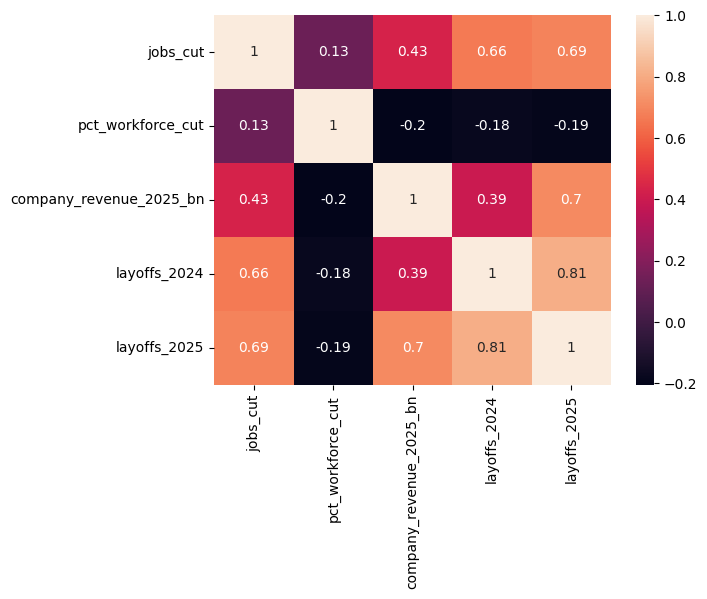

In [123]:
sns.heatmap(df[['jobs_cut','pct_workforce_cut','company_revenue_2025_bn','layoffs_2024','layoffs_2025']].corr(), annot=True)

heatmp analysis👆<br>

* The strongest correlations are between layoffs_2024, layoffs_2025, and jobs_cut (2026).<br>

* Higher revenue companies (company_revenue_2025_bn) have strong positive correlation with jobs_cut (0.43) and layoffs_2025 (0.70).<br>

* The correlation between 2025 layoffs and 2026 layoffs (0.81) is the strongest in the matrix.

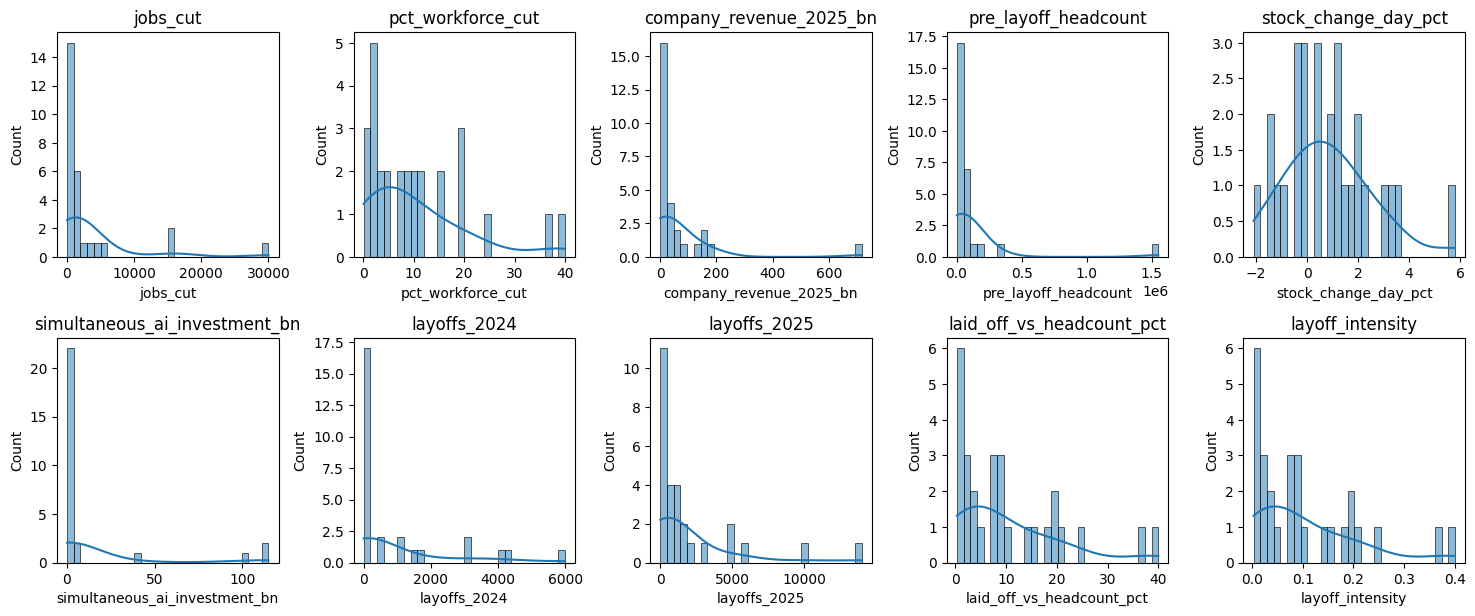

In [125]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(5, 5, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

* In this dataset, the "outliers" (Amazon 16K, Oracle 30K, Meta 16K) are real and very important. They represent major market events.

* Removing them would hide the fact that a few giant companies are responsible for a huge portion of total layoffs.

# Data analysis

1 . Are companies citing AI actually laying off more employees than others?

,total_layoff,avg_layoff_per_company,avg_pct_cut,company_count
ai_cited,,,,
False,39121,2794.357143,9.500000,14
True,62025,4430.357143,11.778571,14


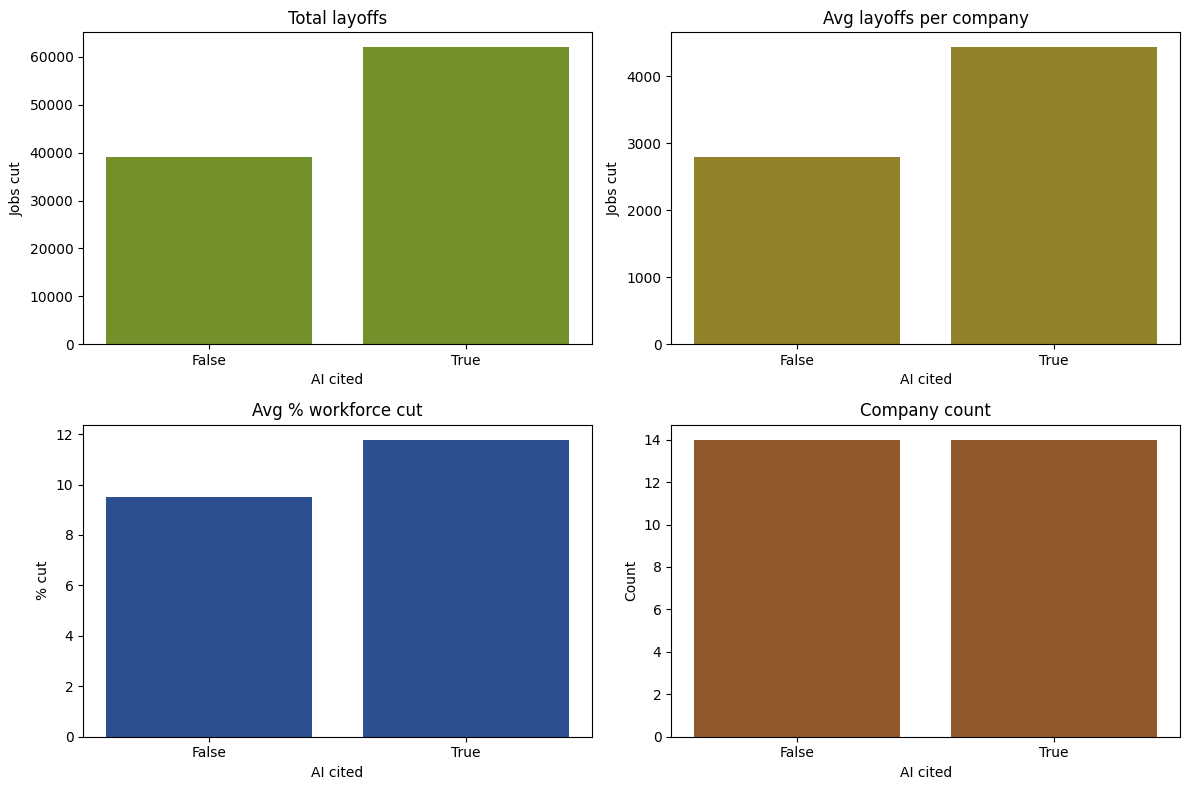

In [68]:
avg_job_cut = df.groupby('ai_cited').agg(
    total_layoff=('jobs_cut' , 'sum'),
    avg_layoff_per_company=('jobs_cut', 'mean'),
    avg_pct_cut=('pct_workforce_cut','mean'),
    company_count=('company', 'count'))
display(avg_job_cut)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax in axes.flat:
    ax.set_xticks([0, 1])                      # positions
    ax.set_xticklabels(['False', 'True'])

# 1) Total layoffs
axes[0, 0].bar(avg_job_cut.index, avg_job_cut['total_layoff'], color="#72912b")
axes[0, 0].set_title('Total layoffs')
axes[0, 0].set_xlabel('AI cited')
axes[0, 0].set_ylabel('Jobs cut')

# 2) Avg layoffs per company
axes[0, 1].bar(avg_job_cut.index, avg_job_cut['avg_layoff_per_company'], color="#91822b")
axes[0, 1].set_title('Avg layoffs per company')
axes[0, 1].set_xlabel('AI cited')
axes[0, 1].set_ylabel('Jobs cut')

# 3) Avg % workforce cut
axes[1, 0].bar(avg_job_cut.index, avg_job_cut['avg_pct_cut'], color="#2b4f91")
axes[1, 0].set_title('Avg % workforce cut')
axes[1, 0].set_xlabel('AI cited')
axes[1, 0].set_ylabel('% cut')

# 4) Company count
axes[1, 1].bar(avg_job_cut.index, avg_job_cut['company_count'], color="#91592b")
axes[1, 1].set_title('Company count')
axes[1, 1].set_xlabel('AI cited')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

<Axes: xlabel='ai_cited', ylabel='jobs_cut'>

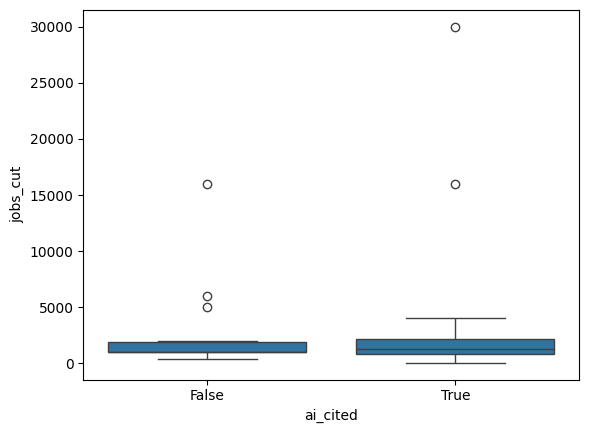

In [55]:
sns.boxplot(data=df, x='ai_cited', y='jobs_cut')

2 . Which industries are most vulnerable to layoffs in 2026?

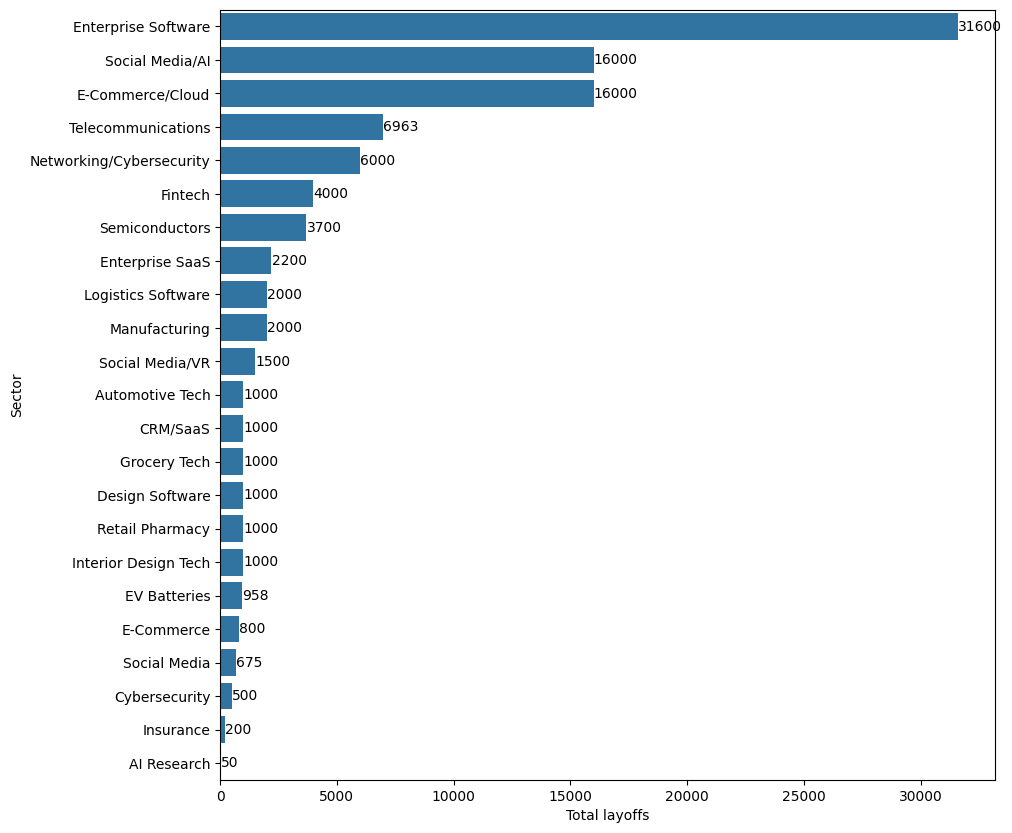

In [6]:
industry_layoff = df.groupby('sector').agg(total_layoff=('jobs_cut', 'sum'))
industry_layoff = industry_layoff.sort_values('total_layoff',ascending=False)  # optional: sort for nicer view

plt.figure(figsize=(10, 10))
ax = sns.barplot(
    x=industry_layoff['total_layoff'],   # numbers on X
    y=industry_layoff.index,            # sectors on Y
    orient='h'                          # explicitly horizontal (optional when y is categorical)
)

# add data labels at the end of bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 5,                 # x position just after bar end
                p.get_y() + p.get_height()/2,
                int(width),
                va='center')

plt.xlabel("Total layoffs")
plt.ylabel("Sector")
plt.show()

3 . Do larger companies lay off more aggressively or more conservatively?

In [84]:
bins = [0 , 10000 , 50000 , 200000 , float("inf")]
labels = ['small(<10k)' , 'Mid(10k-50k)','Large(50k-200k)','Very Large(>200k)']
df['emp_size'] = pd.cut(df["pre_layoff_headcount"], bins=bins, labels=labels)
df['layoff_intensity'] = df['jobs_cut'] / df['pre_layoff_headcount']
# aggressively_layoff = df.groupby('emp_size').agg(
#     avg_workforce_cut = ('pct_workforce_cut' , 'mean'),
#     total_layoff = ('jobs_cut' , 'sum')
# )
aggressively_layoff = df.groupby('emp_size')['layoff_intensity'].mean()
aggressively_layoff = pd.DataFrame(aggressively_layoff)
aggressively_layoff

,layoff_intensity
emp_size,
small(<10k),0.198984
Mid(10k-50k),0.073673
Large(50k-200k),0.059224
Very Large(>200k),0.006749


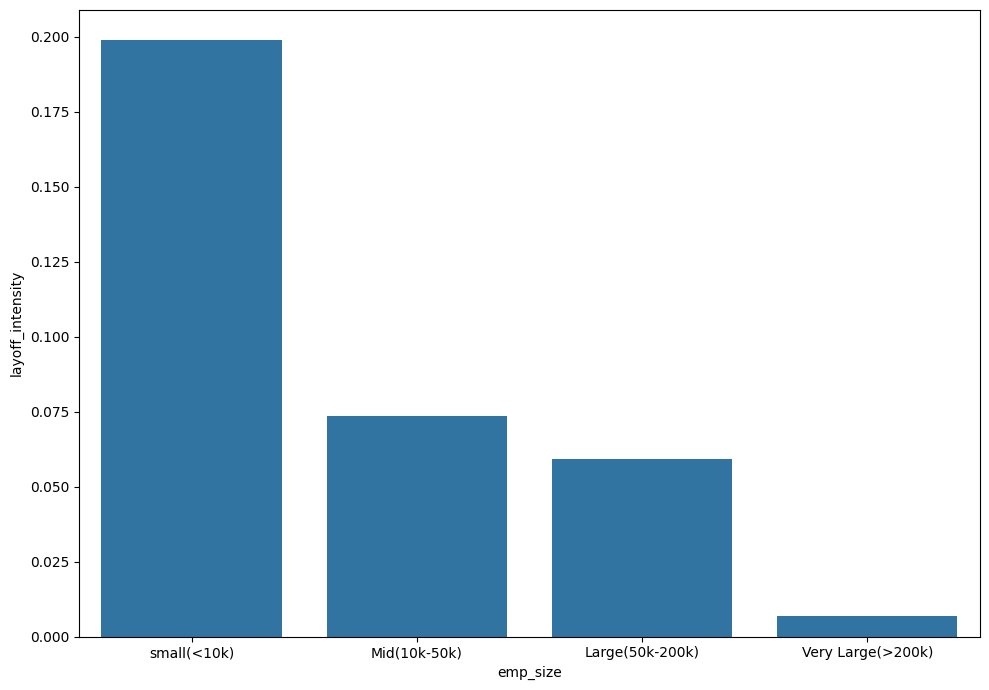

In [83]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=aggressively_layoff,
    x='emp_size', y='layoff_intensity'
)

plt.tight_layout()
plt.show()

4 . Do layoffs positively impact stock sentiment?

In [ ]:
stock_impact = df.groupby('stock_reaction').agg(
    avg_workforce_cut = ('pct_workforce_cut' , 'mean'),
    total_layoff = ('jobs_cut' , 'sum')
)
stock_impact

,avg_workforce_cut,total_layoff
stock_reaction,,
Negative,11.287500,13021
Neutral,6.333333,1250
Positive,11.094118,86875


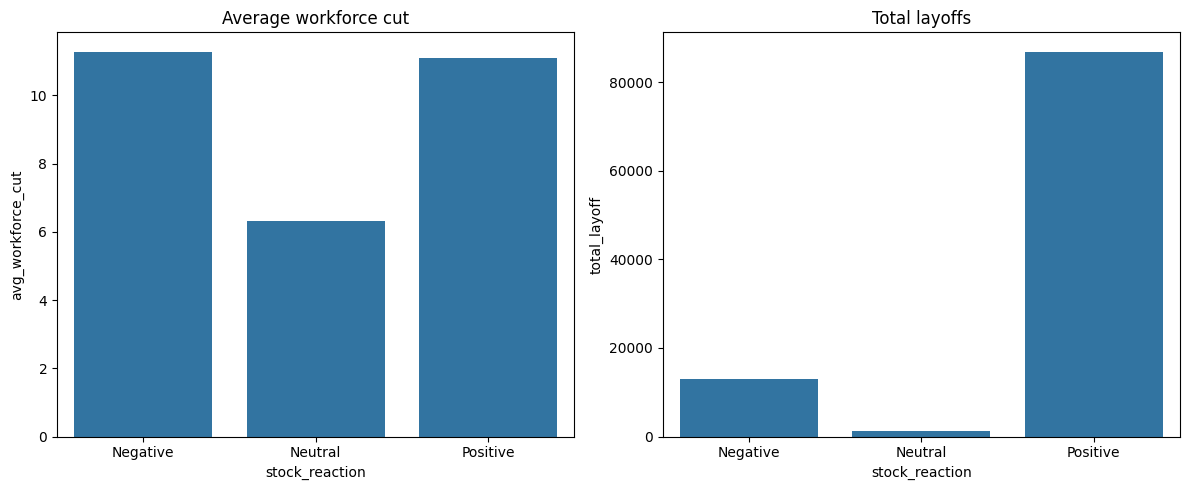

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

sns.barplot(
    data=stock_impact,
    x='stock_reaction', y='avg_workforce_cut', ax=axes[0]
)
axes[0].set_title('Average workforce cut')

sns.barplot(
    data=stock_impact,
    x='stock_reaction', y='total_layoff', ax=axes[1]
)
axes[1].set_title('Total layoffs')

plt.tight_layout()
plt.show()

5 . Are layoffs increasing or decreasing over time in 2026?

In [ ]:
df['layoff_date'] = pd.to_datetime(df['layoff_date'])
df["layoff_month_num"]  = df["layoff_date"].dt.month
df["layoff_month_name"] = df["layoff_date"].dt.strftime("%b")

increse_layoff = df.groupby(['layoff_month_num','layoff_month_name']).agg(
    total_job_cuts = ('jobs_cut' , 'sum'),
)
increse_layoff.sort_values('layoff_month_num')

,,total_job_cuts
layoff_month_num,layoff_month_name,
1,Jan,32800
2,Feb,46588
3,Mar,21758


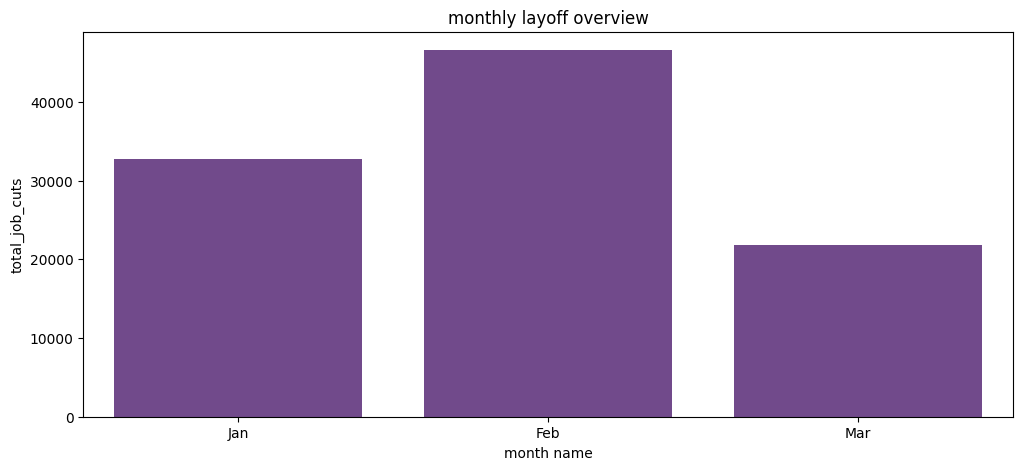

In [94]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=increse_layoff,
    x='layoff_month_name', y='total_job_cuts',
    color="#733f96"
)
plt.title("monthly layoff overview")
plt.xlabel("month name")
plt.ylabel("total_job_cuts")
plt.show()

6 . Which regions are most affected by layoffs?

In [119]:
regions_layoff = df.groupby('region').agg(
    total_layoff = ('jobs_cut' , 'sum'),
    avg_layoff = ('jobs_cut' , 'mean'),
    company_count=('company', 'count')
)
regions_layoff

,total_layoff,avg_layoff,company_count
region,,,
Asia-Pacific,4600,1533.333333,3
Europe,11500,1916.666667,6
North America,85046,4476.105263,19


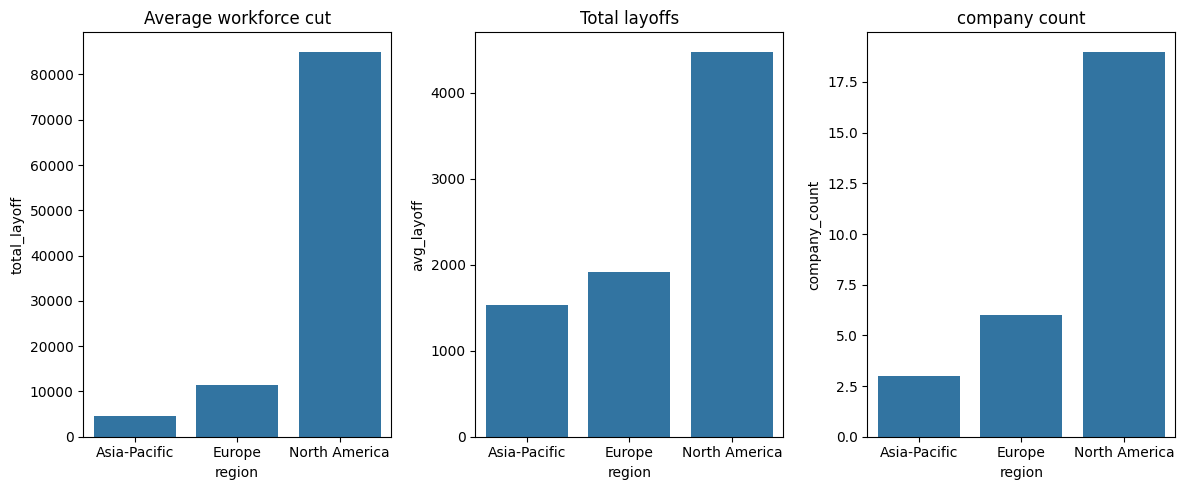

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(12,5), sharex=True)

sns.barplot(
    data=regions_layoff,
    x='region', y='total_layoff', ax=axes[0]
)
axes[0].set_title('Average workforce cut')

sns.barplot(
    data=regions_layoff,
    x='region', y='avg_layoff', ax=axes[1]
)
axes[1].set_title('Total layoffs')

sns.barplot(
    data = regions_layoff , 
    x = 'region'  ,y = 'company_count' , ax = axes[2]
)
axes[2].set_title("company count")
plt.tight_layout()
plt.show()

7. What are the most common reasons behind layoffs?

In [116]:
reason_count = df['reason_stated'].value_counts().head(10)
reason_percent = (df['reason_stated'].value_counts(normalize=True) * 100).head(10).round(2)
reason_percent

reasons_df = pd.DataFrame({
    'count' : reason_count , 
    'per%' : reason_percent
})
print("=== Top 10 Most Common Reasons for Layoffs in 2026 ===\n")
print(reasons_df)

=== Top 10 Most Common Reasons for Layoffs in 2026 ===

                                          count  per%
reason_stated                                        
AI-driven efficiency and restructuring        1  3.57
Reduce bureaucracy and management layers      1  3.57
Declining 5G demand and cost reduction        1  3.57
Cost restructuring with compensation          1  3.57
Pivot from metaverse to AI research           1  3.57
Chip market slowdown                          1  3.57
Rethinking digital transformation             1  3.57
Post-Ansys acquisition restructuring          1  3.57
AI-forward strategy in customer ops           1  3.57
AI investment and office space reduction      1  3.57


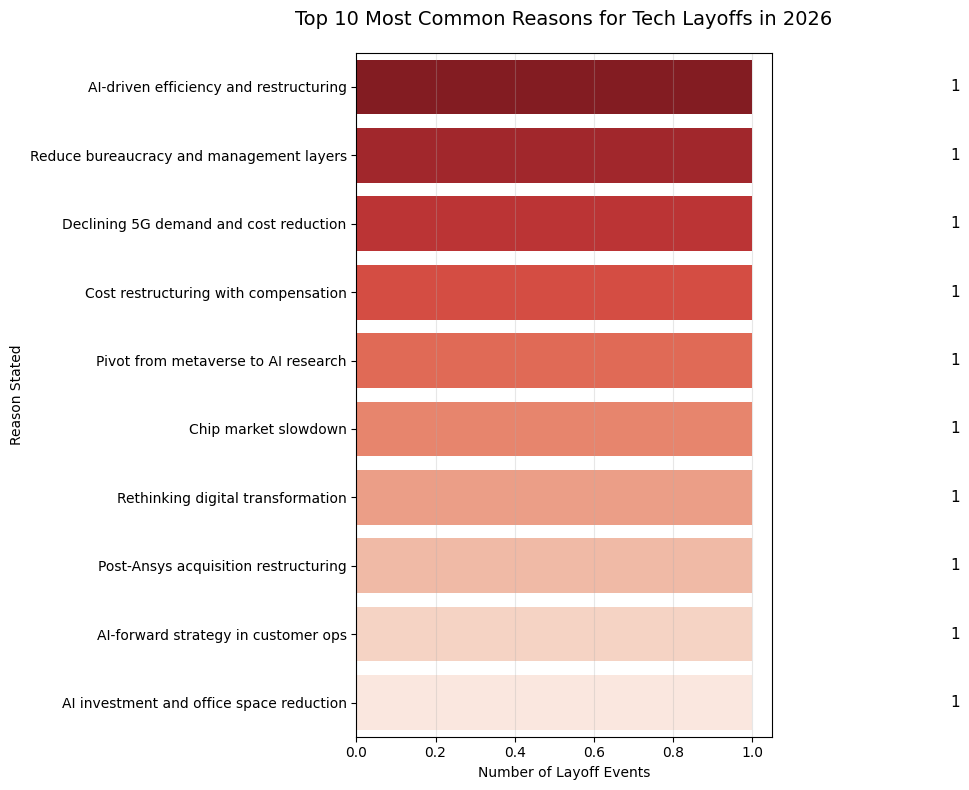

In [117]:
plt.figure(figsize=(12, 8))

# Bar chart - Top 10 Reasons
sns.barplot(data=reasons_df, 
            y='reason_stated', 
            x='count', 
            palette='Reds_r')

plt.title('Top 10 Most Common Reasons for Tech Layoffs in 2026', fontsize=14, pad=20)
plt.xlabel('Number of Layoff Events')
plt.ylabel('Reason Stated')
plt.grid(axis='x', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(reasons_df['count']):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.show()

8 . How do different layoff sizes impact workforce and stock reaction?

In [ ]:
size_impact = df.groupby('layoff_size_category').agg(
    avg_pct_cut=('pct_workforce_cut', 'mean'),
    avg_stock_change=('stock_change_day_pct', 'mean'),
    total_layoffs=('jobs_cut', 'sum'),
    num_events=('company', 'count')
).round(2)

# Stock reaction distribution
reaction = pd.crosstab(df['layoff_size_category'], df['stock_reaction'], normalize='index') * 100

print("=== Layoff Size Impact Summary ===\n")
display(size_impact)
print("====stock reaction distribution=====")
display(reaction.round(1))

# layoff_stock_reaction = (
#     df.groupby(['layoff_size_category', 'stock_reaction'])['pct_workforce_cut']
#       .mean()
#       .reset_index()
#       .rename(columns={'pct_workforce_cut': 'avg_workforce_cut'})
#       .sort_values('avg_workforce_cut', ascending=False)
# )

# display(layoff_stock_reaction)

=== Layoff Size Impact Summary ===



,avg_pct_cut,avg_stock_change,total_layoffs,num_events
layoff_size_category,,,,
Large (2K-5K),17.83,2.67,11200,3
Medium (500-2K),11.39,0.46,20833,17
Mega (5K+),11.18,1.80,68000,4
Small (<500),1.52,0.05,1113,4


====stock reaction distribution=====


stock_reaction,Negative,Neutral,Positive
layoff_size_category,,,
Large (2K-5K),0.0,0.0,100.0
Medium (500-2K),35.3,5.9,58.8
Mega (5K+),25.0,0.0,75.0
Small (<500),25.0,50.0,25.0


In [95]:
pd.crosstab(df['layoff_size_category'], df['stock_reaction'])

stock_reaction,Negative,Neutral,Positive
layoff_size_category,,,
Large (2K-5K),0,0,3
Medium (500-2K),6,1,10
Mega (5K+),1,0,3
Small (<500),1,2,1


9 . Are layoffs increasing compared to previous years?

<Figure size 1000x600 with 0 Axes>

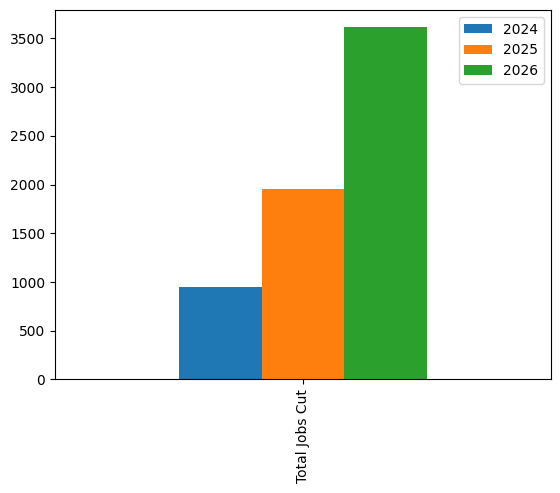

In [118]:
# Yearly comparison
yearly = pd.DataFrame({
    '2024': df['layoffs_2024'].mean(),
    '2025': df['layoffs_2025'].mean(),
    '2026': df['jobs_cut'].mean()
}, index=['Total Jobs Cut'])
yearly

plt.figure(figsize=(10,6))
yearly.plot(kind="bar")
plt.show()

10 . Does AI adoption lead to deeper workforce cuts?

In [53]:
adoption = df.groupby('ai_cited').agg(
    avg_pct = ('pct_workforce_cut' , 'mean'),
)
adoption

,avg_pct
ai_cited,
False,9.500000
True,11.778571


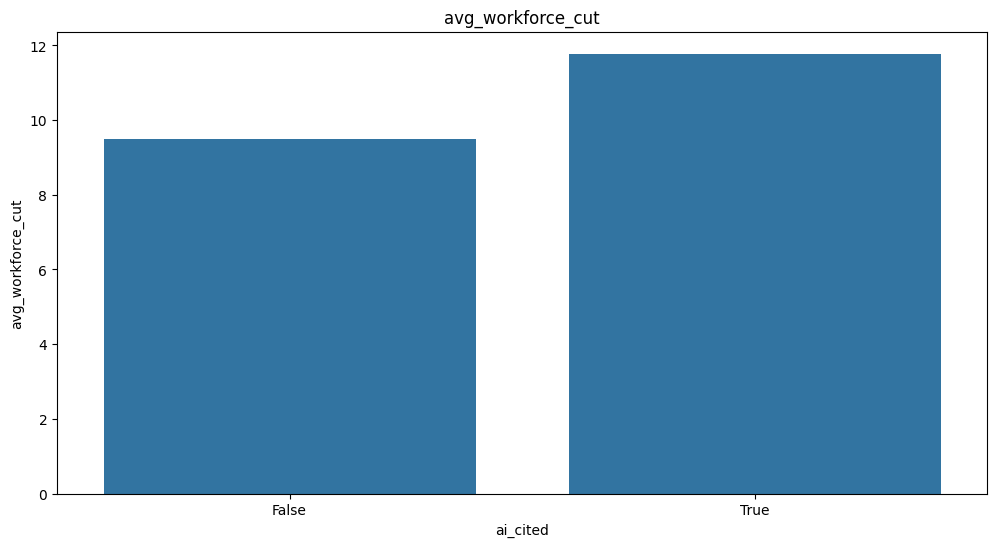

In [54]:
plt.figure(figsize=(12, 6))
sns.barplot(data=adoption , x='ai_cited' , y = 'avg_pct')
plt.title("avg_workforce_cut")
plt.xlabel("ai_cited")
plt.ylabel('avg_workforce_cut')
plt.show()